# Converting to OME-Zarr

In the last notebook, we looked at how to create an OME-Zarr image with a combination of `zarr-python` and `ome-zarr-models`.

There are many packages out there that focus on simplifying conversion of datasets to OME-Zarr. We'll look at `bioio-ome-zarr` as an example - but bear in mind there are many more options! Packages differ in the features they support, as well as how memory-efficient they are during conversion of large datasets, so it's worth trying a few different options and browsing [image.sc](https://forum.image.sc/) for advice.

In [18]:
from bioio_ome_zarr.writers import OMEZarrWriter, Channel
from ome_zarr_models.v05.image import Image
import matplotlib.pyplot as plt
import zarr
import math

## bioio-ome-zarr

Let's load the same heart image as a numpy array again:

In [9]:
# heart image loaded as a numpy array
heart_np = zarr.open_array("data/hoa_heart.zarr")[:]

print(heart_np.shape)

(120, 120, 139)


Now let's make an OME-Zarr with 4 resolution levels with `bioio-ome-zarr`:

In [12]:
# Shapes of each resolution level you want to make
level_shapes = [
    heart_np.shape,  # full res
    tuple(math.ceil(i / 2) for i in heart_np.shape),  # 2x smaller
    tuple(math.ceil(i / 4) for i in heart_np.shape),  # 4x smaller
    tuple(math.ceil(i / 8) for i in heart_np.shape)  # 8x smaller
]

# Writer with any additional metadata required
writer = OMEZarrWriter(
    store="data/heart-bioio.ome.zarr",
    level_shapes=level_shapes,
    dtype=heart_np.dtype,
    zarr_format=3,
    axes_names=["x", "y", "z"],
    axes_types=["space", "space", "space"],
    axes_units=["um", "um", "um"],
)

writer.write_full_volume(heart_np)

Let's run it through ome-zarr-models - is it valid?

In [15]:
zarr_group = zarr.open_group("data/heart-bioio.ome.zarr")
print(zarr_group.tree())

/
├── 0 (120, 120, 139) uint8
├── 1 (60, 60, 70) uint8
├── 2 (30, 30, 35) uint8
└── 3 (15, 15, 18) uint8

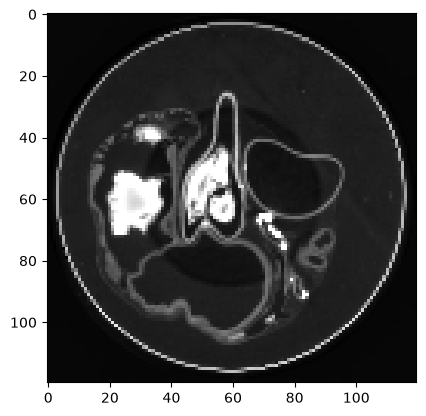

In [22]:
# plot a slice through the full resolution
plt.imshow(zarr_group["0"][:, :, 60], cmap="gray")

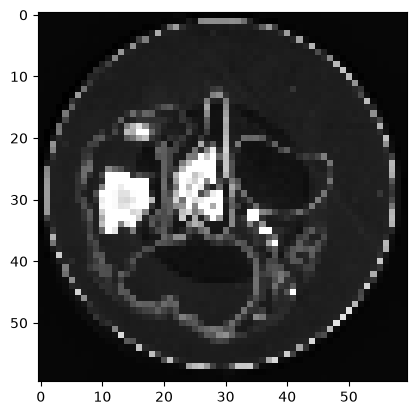

In [27]:
# plot a slice through the resolution level 1
plt.imshow(zarr_group["1"][:, :, 30], cmap="gray")

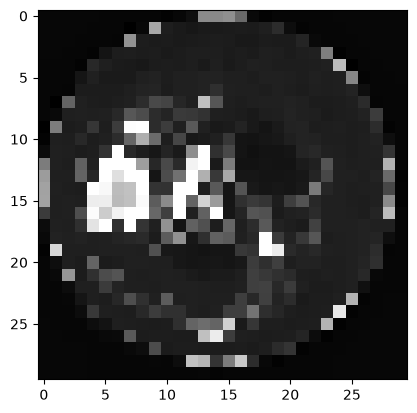

In [28]:
# plot a slice through the resolution level 2
plt.imshow(zarr_group["2"][:, :, 15], cmap="gray")

## Stretch Exercise

Try doing the same conversion with another package from the ngff docs [converter list](https://ngff.openmicroscopy.org/resources/tools/index.html#zarr-converters) and [writer list](https://ngff.openmicroscopy.org/resources/tools/index.html#zarr-readers-writers).

For example:
- [ngff-zarr](https://ngff-zarr.readthedocs.io/en/latest/python.html)
- [stack-to-chunk](https://stack-to-chunk.readthedocs.io/en/stable/)
- ...

Or try converting some of your own data to OME-Zarr.

## Key take-aways

In summary, we have learnt that:
- There are a variety of packages that can simplify conversion of datasets to OME-Zarr
- The [ngff docs](https://ngff.openmicroscopy.org/resources/tools/index.html) are a good place to find suitable packages
- `bioio-ome-zarr` is one example of a package that can handle conversion